In [1]:
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

/Users/briancolclough/Documents/Coding/Applied-machine-learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/briancolclough/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [2]:
import os
# list files in the path
print(os.listdir(path))

['creditcard.csv']


In [3]:
creditcard_path = os.path.join(path, 'creditcard.csv')
data = pd.read_csv(creditcard_path)
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Examine features
print(data.columns)
# Examine the class distribution
print("\nClass distribution:")
print(data['Class'].value_counts())

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


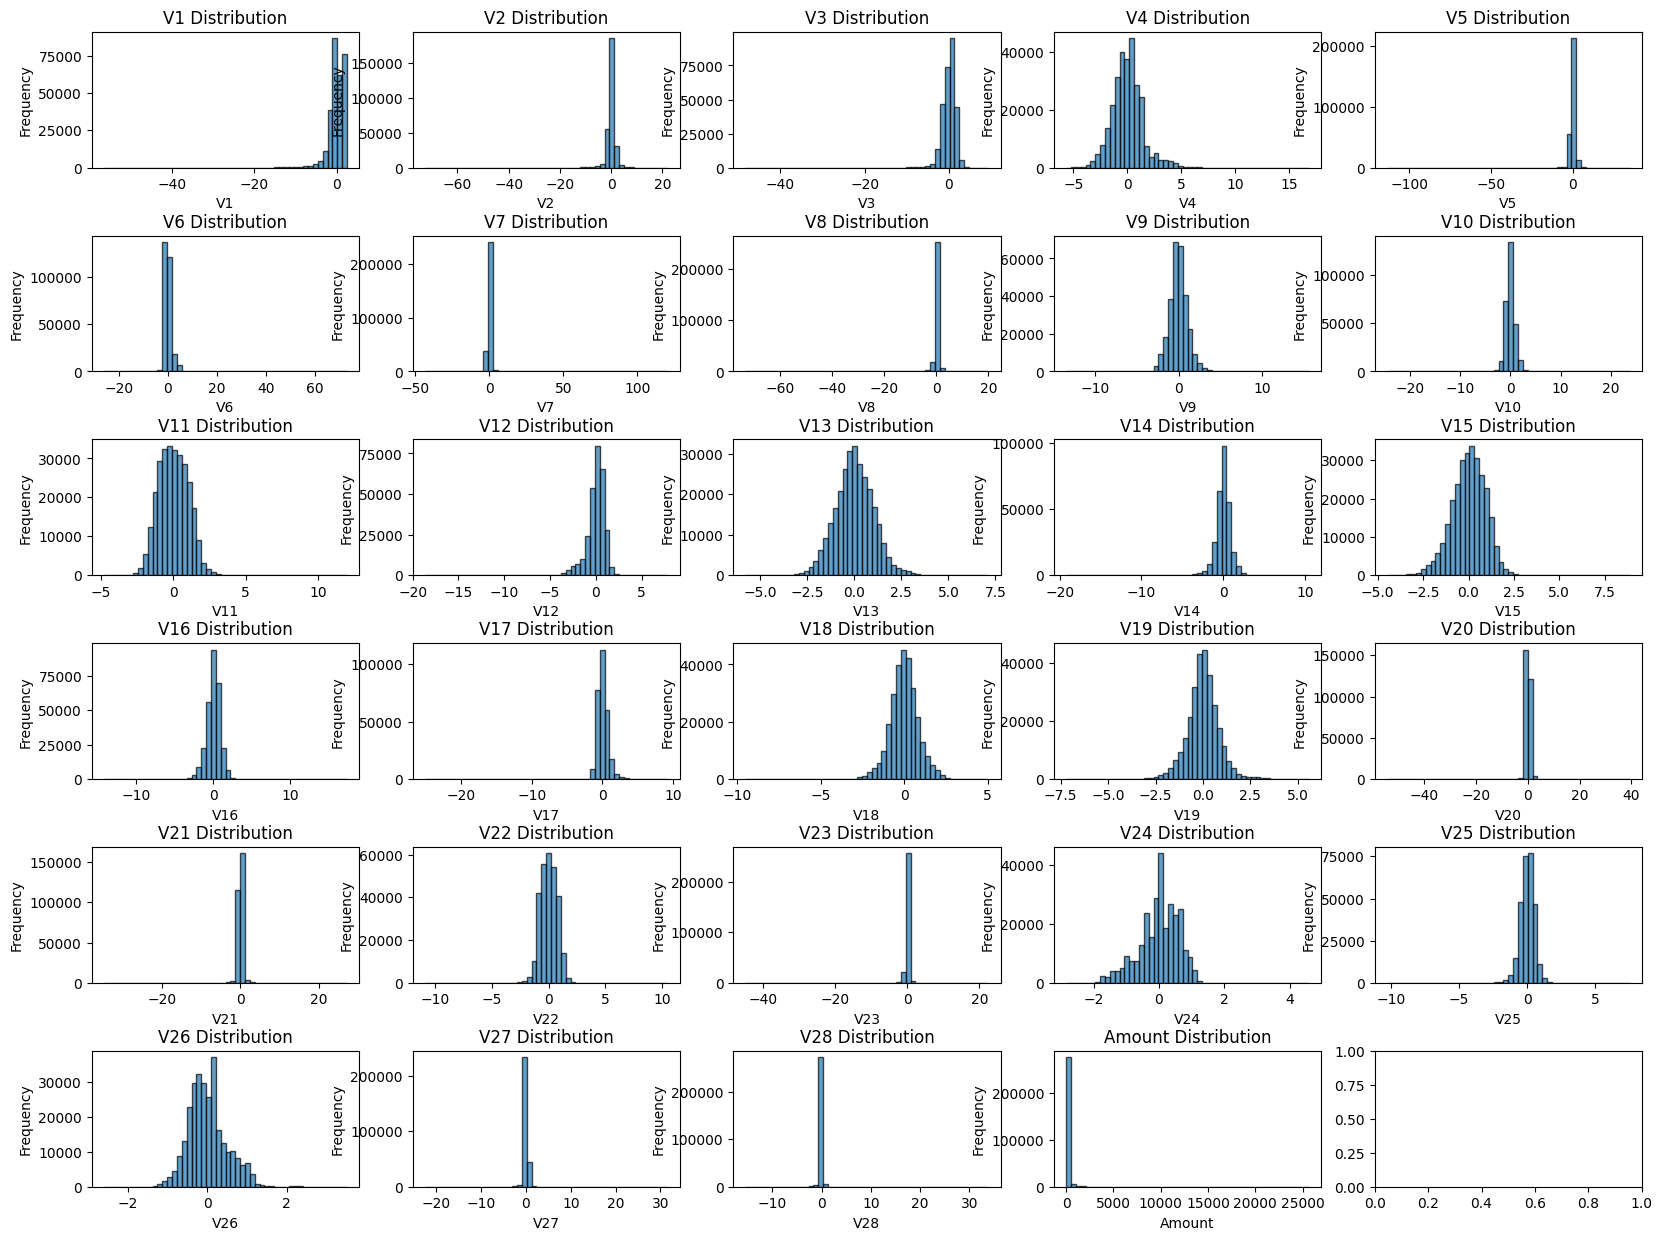


Summary Statistics:
                 V1            V2            V3            V4            V5  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15  1.021879e-15   
std    1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00  1.380247e+00   
min   -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00 -1.137433e+02   
25%   -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01 -6.915971e-01   
50%    1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02 -5.433583e-02   
75%    1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01  6.119264e-01   
max    2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01  3.480167e+01   

                 V6            V7            V8            V9           V10  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15  2.238554e-15   
std    1.332271e+00  1.237094e

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get all feature columns (excluding Time and Class)
feature_cols = [col for col in data.columns if col not in ['Time', 'Class']]

# Create histograms for all features
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 15))
axes = axes.flatten()

plt.subplots_adjust(hspace=0.5)

for idx, col in enumerate(feature_cols):
    axes[idx].hist(data[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.show()

print("\nSummary Statistics:")
print(data[feature_cols].describe())



# Evaluation Metric

Since most transactions are *not* fraud, if we had a model that guessed non-fraud for all transactions, it would have a very high accuracy. For this reason, we need a different metric. In this case, we want to use Recall, Precision, and F1-score. I'll primarily focus on F1-score to get a more balanced look at precision and recall, but if we were trying to minimize false fraud alerts, we could focus more on precision so as not to disrupt regular card users, or focus on recall if catching all frauds was the priority.

# Question 3 - Standarization or Normalization

Looking at our data the main features (V1-V28) are already standarized. To finish pre-processing this dataset we can drop the time column as this is not a predictive feature here, and we can standarize the amount column, since that is the only column that is not currently standarized. The classifiers we're using (SVC and MLPClassifier) are sensitive to feature scales. Features with larger ranges can dominate the learning process and impact model performance. By standardizing Amount to match the scale of V1-V28, we can be sure all features contribute equally to the model.

In [6]:
from sklearn.preprocessing import StandardScaler

preprocessed_data = data.copy()
preprocessed_data['Amount'] = StandardScaler().fit_transform(preprocessed_data[['Amount']])
preprocessed_data = preprocessed_data.drop(columns=['Time'])

preprocessed_data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,0


In [7]:
from sklearn.model_selection import train_test_split

X = preprocessed_data.drop(columns=['Class'])
y = preprocessed_data['Class']

# 50/50 split on data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

X_train.head()


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
126247,1.149907,0.020216,-0.095297,1.029788,0.426260,0.809204,-0.037762,0.211147,0.143879,0.039982,...,-0.100386,-0.112573,-0.191762,-0.240985,-1.145808,0.770264,-0.259460,0.027821,-0.001762,-0.208419
42508,1.156724,0.411155,0.915068,2.512448,-0.496515,-0.436129,-0.141861,0.028122,-0.384754,0.700740,...,-0.214952,-0.106942,-0.440053,0.082861,0.325173,0.251069,-0.126533,-0.005867,0.028982,-0.307131
122710,1.155467,-0.082742,0.772878,0.406323,-0.470132,0.248047,-0.550436,0.263281,0.199039,0.051862,...,-0.116218,-0.031563,-0.112790,0.071490,-0.299515,0.087012,0.246823,0.002631,0.009327,-0.317287
143965,1.237639,0.313789,0.194803,0.497667,-0.132052,-0.554997,-0.007754,-0.049065,-0.240606,-0.120077,...,-0.044824,-0.255061,-0.758196,0.073909,-0.030451,0.238024,0.096570,-0.025675,0.017739,-0.348072
100207,1.086681,0.552043,-0.224936,2.518481,0.375527,-0.262240,0.315264,-0.076407,-0.699289,0.187612,...,0.038884,-0.269292,-1.025118,-0.098165,-0.595574,0.419725,-0.142003,-0.017693,0.054833,-0.018869


Classifiers without regularization or tree pruning
- svc
- decision tree
- MLP classifier
- Random Forest

In [8]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# Train the SVC model
svc_model = SVC(kernel='rbf', C=1, gamma='auto')
svc_model.fit(X_train, y_train)

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

mlp_classifier = MLPClassifier(random_state=42)
mlp_classifier.fit(X_train, y_train)

random_forest_model = RandomForestClassifier(random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score
# report model performance

def report_model_performance(model, X_test, y_test, feature_cols):
    predictions = model.predict(X_test)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    print(f"Model: {model.__class__.__name__}")
    print(f"Precision: {precision}, Recall: {recall}, F1-score: {f1}")
    return precision, recall, f1


report_model_performance(svc_model, X_test, y_test, feature_cols)
print("-"*100)
report_model_performance(decision_tree_model, X_test, y_test, feature_cols)
print("-"*100)
report_model_performance(mlp_classifier, X_test, y_test, feature_cols)
print("-"*100)
report_model_performance(random_forest_model, X_test, y_test, feature_cols)


Model: SVC
Precision: 0.9743589743589743, Recall: 0.6178861788617886, F1-score: 0.7562189054726368
----------------------------------------------------------------------------------------------------
Model: DecisionTreeClassifier
Precision: 0.7410358565737052, Recall: 0.7560975609756098, F1-score: 0.7484909456740443
----------------------------------------------------------------------------------------------------
Model: MLPClassifier
Precision: 0.8786407766990292, Recall: 0.7357723577235772, F1-score: 0.8008849557522124
----------------------------------------------------------------------------------------------------
Model: RandomForestClassifier
Precision: 0.9633507853403142, Recall: 0.7479674796747967, F1-score: 0.8421052631578947


(0.9633507853403142, 0.7479674796747967, 0.8421052631578947)

In [10]:
from sklearn.model_selection import GridSearchCV

# add regularization and/or tree pruning
# preform grid search to find best parameters for decision tree

decision_tree_model = DecisionTreeClassifier(random_state=42)
 
tree_params = {
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}


tree_grid_search = GridSearchCV(estimator=decision_tree_model, param_grid=tree_params, cv=5, scoring='f1', n_jobs=-1)
tree_grid_search.fit(X_train, y_train)


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [11]:
print('model params:')
print(tree_grid_search.best_estimator_.get_params())

# report model performance

report_model_performance(tree_grid_search.best_estimator_, X_test, y_test, feature_cols)


model params:
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}
Model: DecisionTreeClassifier
Precision: 0.8761467889908257, Recall: 0.7764227642276422, F1-score: 0.8232758620689655


(0.8761467889908257, 0.7764227642276422, 0.8232758620689655)

In [12]:
# MLP Classifier

mlp_classifier = MLPClassifier(random_state=42)

mlp_params = {
    'hidden_layer_sizes': [(30,), (50,), (100,)],
    'activation': ['relu', 'tanh', 'logistic'],
    'alpha': [0.0001, 0.001, 0.01],
}

mlp_grid_search = GridSearchCV(estimator=mlp_classifier, param_grid=mlp_params, cv=5, scoring='f1', n_jobs=-1)
mlp_grid_search.fit(X_train, y_train)


,estimator,MLPClassifier(random_state=42)
,param_grid,"{'activation': ['relu', 'tanh', ...], 'alpha': [0.0001, 0.001, ...], 'hidden_layer_sizes': [(30,), (50,), ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(100,)"


In [13]:
print('model params:')
print(mlp_grid_search.best_estimator_.get_params())

report_model_performance(mlp_grid_search.best_estimator_, X_test, y_test, feature_cols)


model params:
{'activation': 'tanh', 'alpha': 0.0001, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 200, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}
Model: MLPClassifier
Precision: 0.9753086419753086, Recall: 0.6422764227642277, F1-score: 0.7745098039215687


(0.9753086419753086, 0.6422764227642277, 0.7745098039215687)

In [ ]:
# svc classifier

svc_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
}

svc_grid_search = GridSearchCV(estimator=svc_model, param_grid=svc_params, cv=5, scoring='f1', n_jobs=-1)
svc_grid_search.fit(X_train, y_train)

In [ ]:

print('model params:')
print(svc_grid_search.best_estimator_.get_params())

report_model_performance(svc_grid_search.best_estimator_, X_test, y_test, feature_cols)

## Creating a nural network using PyTorch

In [16]:
from torch import nn
from torch import optim
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np

# Define a single hidden layer neural network
class SingleLayerNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SingleLayerNN, self).__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Forward pass through the network
        logits = self.linear_relu_stack(x)
        return logits

In [17]:
import torch
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)


### Model Params

In [18]:
# Number of features
input_size = X_train.shape[1]  
# Number of neurons in hidden layer
hidden_size = 64 
# output size 1 since were doing binary classification
output_size = 1   


In [19]:
def train_model(model):

    # Loss function and optimizer
    criterion = nn.BCELoss()  # Binary Cross Entropy Loss
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training parameters
    num_epochs = 100
    batch_size = 256

    # Training loop
    print("Training the model...")
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        # Mini-batch training
        for i in range(0, len(X_train_tensor), batch_size):
            batch_X = X_train_tensor[i:i+batch_size]
            batch_y = y_train_tensor[i:i+batch_size]
            
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss/len(X_train_tensor):.6f}')


In [20]:
# Initialize the model
singleLayerNN = SingleLayerNN(input_size, hidden_size, output_size)

In [21]:
train_model(singleLayerNN)

Training the model...
Epoch [10/100], Loss: 0.000007
Epoch [20/100], Loss: 0.000004
Epoch [30/100], Loss: 0.000002
Epoch [40/100], Loss: 0.000002
Epoch [50/100], Loss: 0.000002
Epoch [60/100], Loss: 0.000002
Epoch [70/100], Loss: 0.000001
Epoch [80/100], Loss: 0.000001
Epoch [90/100], Loss: 0.000001
Epoch [100/100], Loss: 0.000001


In [22]:
def evaluate_model(model):
    # Evaluation
    model.eval()
    with torch.no_grad():
        # Predictions on test set
        y_pred = model(X_test_tensor)
        y_pred_class = (y_pred > 0.5).float()
        
        # Calculate metrics
        accuracy = (y_pred_class == y_test_tensor).sum().item() / len(y_test_tensor)
        f1 = f1_score(y_test_tensor.numpy(), y_pred_class.numpy())
        
        print(f'Training Accuracy: {accuracy:.4f}')
        print(f'\nTest Accuracy: {accuracy:.4f}')
        print(f'F1 Score: {f1:.4f}')
        print('\nClassification Report:')
        print(classification_report(y_test_tensor.numpy(), y_pred_class.numpy()))
        print('\nConfusion Matrix:')
        print(confusion_matrix(y_test_tensor.numpy(), y_pred_class.numpy()))


In [23]:
evaluate_model(singleLayerNN)

Training Accuracy: 0.9994

Test Accuracy: 0.9994
F1 Score: 0.7945

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    142158
         1.0       0.92      0.70      0.79       246

    accuracy                           1.00    142404
   macro avg       0.96      0.85      0.90    142404
weighted avg       1.00      1.00      1.00    142404


Confusion Matrix:
[[142143     15]
 [    74    172]]


In [24]:
class SingleLayerNNWithDropout(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SingleLayerNNWithDropout, self).__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Forward pass through the network
        logits = self.linear_relu_stack(x)
        return logits

In [25]:
dropout_model = SingleLayerNNWithDropout(input_size, hidden_size, output_size)

train_model(dropout_model)

Training the model...
Epoch [10/100], Loss: 0.000010
Epoch [20/100], Loss: 0.000009
Epoch [30/100], Loss: 0.000008
Epoch [40/100], Loss: 0.000008
Epoch [50/100], Loss: 0.000007
Epoch [60/100], Loss: 0.000007
Epoch [70/100], Loss: 0.000007
Epoch [80/100], Loss: 0.000006
Epoch [90/100], Loss: 0.000006
Epoch [100/100], Loss: 0.000006


In [26]:
evaluate_model(dropout_model)

Training Accuracy: 0.9994

Test Accuracy: 0.9994
F1 Score: 0.8000

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    142158
         1.0       0.88      0.73      0.80       246

    accuracy                           1.00    142404
   macro avg       0.94      0.87      0.90    142404
weighted avg       1.00      1.00      1.00    142404


Confusion Matrix:
[[142134     24]
 [    66    180]]


## Why more robust models are generally better

The model that we created without using dropout might be overfitting to our train and test data. Since dropout acts as regularization, forcing the network to learn more robust features that generalize better, even if the model performs slightly worse on our test set (F1: ~0.7875 vs ~0.7991), it will likely perform better on completely new data. This is particularly important for fraud detection, where the model needs to maintain performance as new fraud patterns emerge in production.

## Random Forest with 10 fold CV and NN with 10 fold CV

In [ ]:
# Random Forest with 10 fold CV
from sklearn.model_selection import cross_val_score


scores = cross_val_score(random_forest_model, X_train, y_train, cv=10, scoring='f1')
print(f"10-Fold CV F1 Score: {scores.mean():.4f} ({chr(177)} {scores.std() * 2:.4f})")

10-Fold CV F1 Score: 0.8356 (± 0.1081)


In [37]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

def pytorch_10fold_cv(ModelClass, X, y, model_name="PyTorch Model", num_epochs=100, use_dropout=False):
    """
    Perform 10-fold cross-validation on a PyTorch model.
    
    Args:
        ModelClass: The PyTorch model class (SingleLayerNN or SingleLayerNNWithDropout)
        X: Training features (pandas DataFrame or numpy array)
        y: Training labels (pandas Series or numpy array)
        model_name: Name for printing results
        num_epochs: Number of training epochs
        use_dropout: Whether the model uses dropout (affects train/eval mode)
    """
    X = X.values
    y = y.values
    
    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    f1_scores = []
    
    # Model hyperparameters from your setup
    input_size = X.shape[1]
    hidden_size = 64
    output_size = 1
    batch_size = 256
    
    print(f"\n{'='*60}")
    print(f"{model_name} - 10-Fold Cross-Validation")
    print(f"{'='*60}")
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X)):
        # Split data for this fold
        X_fold_train = torch.FloatTensor(X[train_idx])
        y_fold_train = torch.FloatTensor(y[train_idx]).view(-1, 1)
        X_fold_val = torch.FloatTensor(X[val_idx])
        y_fold_val = torch.FloatTensor(y[val_idx]).view(-1, 1)
        
        # Initialize fresh model for this fold
        model = ModelClass(input_size, hidden_size, output_size)
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        # Training loop
        model.train()
        for epoch in range(num_epochs):
            epoch_loss = 0
            
            # Mini-batch training
            for i in range(0, len(X_fold_train), batch_size):
                batch_X = X_fold_train[i:i+batch_size]
                batch_y = y_fold_train[i:i+batch_size]
                
                # Forward pass
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                
                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item()
        
        # Evaluation on validation fold
        model.eval()
        with torch.no_grad():
            y_pred = model(X_fold_val)
            y_pred_class = (y_pred > 0.5).float()
            f1 = f1_score(y_fold_val.numpy(), y_pred_class.numpy())
            f1_scores.append(f1)
        
        print(f"Fold {fold+1:2d}/10: F1 Score = {f1:.4f}")
    
    # Calculate statistics
    f1_scores = np.array(f1_scores)
    mean_f1 = f1_scores.mean()
    std_f1 = f1_scores.std()
    ci_95 = std_f1 * 2  # Approximate 95% confidence interval
    
    print(f"\n{'-'*60}")
    print(f"Mean F1 Score: {mean_f1:.4f} (± {ci_95:.4f})")
    print(f"Std Dev:       {std_f1:.4f}")
    print(f"Min:           {f1_scores.min():.4f}")
    print(f"Max:           {f1_scores.max():.4f}")
    print(f"{'='*60}\n")
    
    return f1_scores

In [36]:
# 10 Fold CV for MLP
scores = pytorch_10fold_cv(
    SingleLayerNN, 
    X_train, 
    y_train, 
    model_name="PyTorch NN (Q6 - No Dropout)",
    num_epochs=75  
)
print(f"10-Fold CV F1 Score: {scores.mean():.4f} ({chr(177)} {scores.std() * 2:.4f})")



PyTorch NN (Q6 - No Dropout) - 10-Fold Cross-Validation
Fold  1/10: F1 Score = 0.7600
Fold  2/10: F1 Score = 0.8936
Fold  3/10: F1 Score = 0.7778
Fold  4/10: F1 Score = 0.9048
Fold  5/10: F1 Score = 0.8163
Fold  6/10: F1 Score = 0.8333
Fold  7/10: F1 Score = 0.7843
Fold  8/10: F1 Score = 0.9153
Fold  9/10: F1 Score = 0.7727
Fold 10/10: F1 Score = 0.8649

------------------------------------------------------------
Mean F1 Score: 0.8323 (± 0.1118)
Std Dev:       0.0559
Min:           0.7600
Max:           0.9153

10-Fold CV F1 Score: 0.8323 (± 0.1118)


In [38]:
# 10 Fold CV for our MLP with dropout
scores = pytorch_10fold_cv(
    SingleLayerNNWithDropout, 
    X_train, 
    y_train, 
    model_name="PyTorch NN (Q7 - With Dropout)",
    num_epochs=100, 
)


PyTorch NN (Q7 - With Dropout) - 10-Fold Cross-Validation
Fold  1/10: F1 Score = 0.8333
Fold  2/10: F1 Score = 0.8235
Fold  3/10: F1 Score = 0.7222
Fold  4/10: F1 Score = 0.9048
Fold  5/10: F1 Score = 0.8302
Fold  6/10: F1 Score = 0.8750
Fold  7/10: F1 Score = 0.7826
Fold  8/10: F1 Score = 0.8421
Fold  9/10: F1 Score = 0.7234
Fold 10/10: F1 Score = 0.8649

------------------------------------------------------------
Mean F1 Score: 0.8202 (± 0.1154)
Std Dev:       0.0577
Min:           0.7222
Max:           0.9048



The 10-fold cross-validation results show that all three models perform similarly, with F1 scores ranging from 0.82 to 0.84 and similar confidence intervals. The Random Forest achieved the best performance (0.8356 ± 0.1081) with the lowest variance, making it the most stable and reliable choice for production fraud detection. Interestingly, the PyTorch neural network with dropout (0.8202 ± 0.1154) performed slightly worse than the model without dropout (0.8323 ± 0.1118) and exhibited higher variance. The cross-validation approach provides substantially more confidence in these estimates compared to the single train-test split results. If I were to run this again I would lower my dropout rate/or do more epochs on my dropdout model to see if that would create a better model.